**Data Analysis**      
***Phenomenon of Culturomics on case of Michael Jackson Wikipedia page***

This notebook contains the three analysis layers of the project:

1.**General Layer** a descriptive view of the three phases of the phenomenon
   (calm period, flashpoint, decay and residue).     
2.**Audience interest drop ( Michel method)**  a simple, direct measurement of how fast the attention spike faded, following the method used by Michel (2011).     
3.**Event Comparison Layer** a comparison between the 2009 flashpoint and the
   2026 secondary spike, to check whether both events left the same kind of
   trace on the article.     

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
pageviews = pd.read_csv("michael_jackson_pageviews.csv", parse_dates=["date"])
revisions = pd.read_csv("michael_jackson_revisions.csv", parse_dates=["timestamp"])
revisions["size_clean"] = revisions["size"].rolling(window=3, center=True, min_periods=1).median()
revisions["size_clean"] = revisions["size_clean"].cummax()


**Layer 1 General Layer**

This step plot the three raw signals of the phenomenon side by side: daily
pageviews, daily edit counts, and cumulative article size.

The Goal is to give a first, descriptive picture of the three phases described in the
theory section: a calm period, a sudden flashpoint, and a lasting change in
article size.

The code must be able to answer to question:      
Do the three signals visibly show the same event, and do they
behave differently from each other after it?

The first  stage of the pipeline is to assign plots, each annotated with the flashpoint date
(25 June 2009).


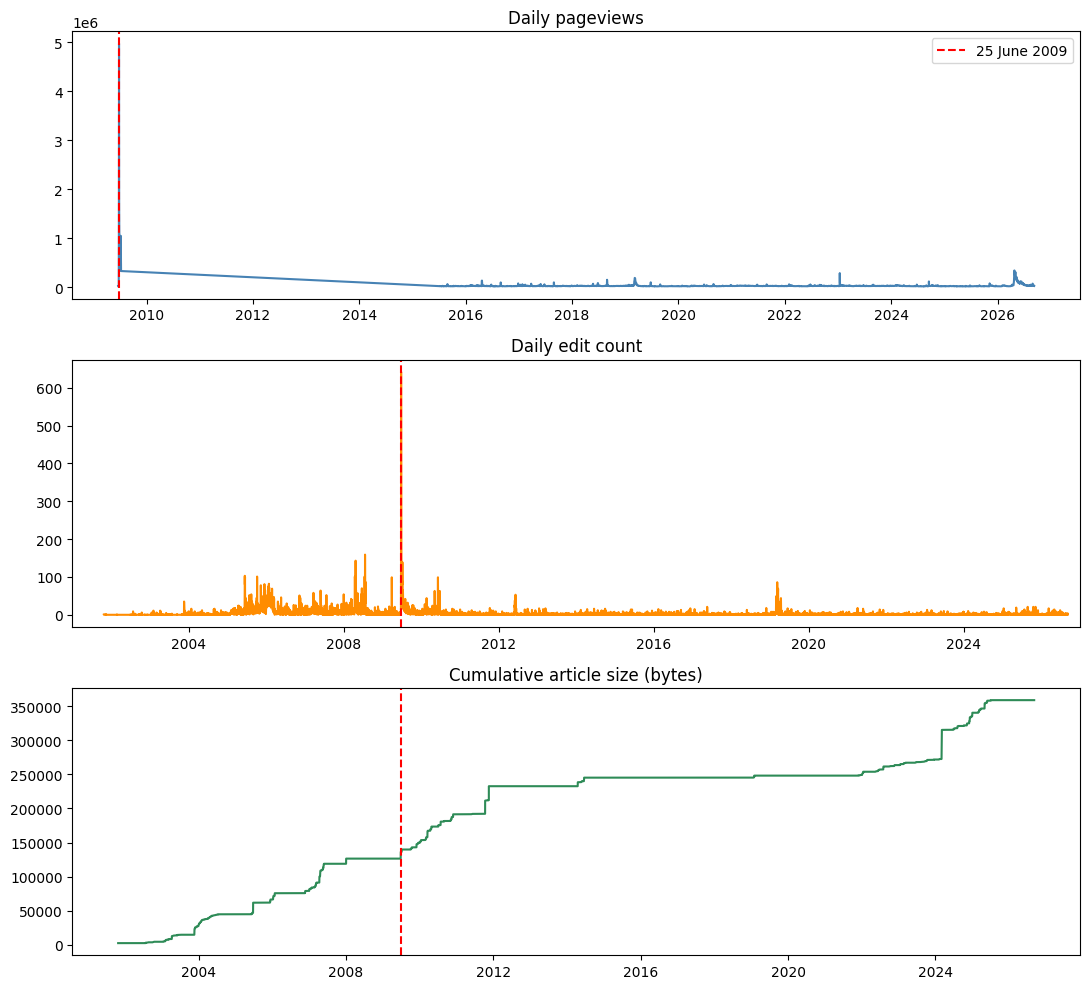

In [7]:
daily_edits = revisions.set_index("timestamp").resample("D").size()

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=False)

axes[0].plot(pageviews["date"], pageviews["views"], color="steelblue")
axes[0].axvline(pd.Timestamp("2009-06-25"), color="red", linestyle="--", label="25 June 2009")
axes[0].set_title("Daily pageviews")
axes[0].legend()

axes[1].plot(daily_edits.index, daily_edits.values, color="darkorange")
axes[1].axvline(pd.Timestamp("2009-06-25"), color="red", linestyle="--")
axes[1].set_xlim(pd.Timestamp("2001-01-01"), pd.Timestamp("2026-12-31"))
axes[1].set_title("Daily edit count")

axes[2].plot(revisions["timestamp"], revisions["size_clean"], color="seagreen")
axes[2].axvline(pd.Timestamp("2009-06-25"), color="red", linestyle="--")
axes[2].set_title("Cumulative article size (bytes)")

plt.tight_layout()
plt.show()


**Layer 2 Audience interest drop ( Michel method)**

This step establish measure how many days it took for pageviews to fall to half of
their peak value after the event.

The Goal is to put one concrete number on the idea of "attention fading away",
instead of only describing the shape of the curve.

The code must be able to answer to question:      
How many days after the peak did attention drop to half of its
highest point?

The second stage of the pipeline is to assign one number (the half-life, in days) and a plot of the decay window.

This follows the same direct method used by Michel (2011): find the peak,
then find the first day after the peak where the value is at or below half of
that peak.


In [8]:
def half_life_michel(dates, values, search_start, search_end):
    window = pd.DataFrame({"date": dates, "views": values})
    window = window[(window["date"] >= search_start) & (window["date"] <= search_end)]
    peak_idx = window["views"].idxmax()
    peak_date = window.loc[peak_idx, "date"]
    peak_value = window.loc[peak_idx, "views"]
    half_value = peak_value / 2

    after_peak = window[window["date"] >= peak_date]
    below_half = after_peak[after_peak["views"] <= half_value]

    if below_half.empty:
        return peak_date, peak_value, None

    half_life_date = below_half["date"].iloc[0]
    return peak_date, peak_value, (half_life_date - peak_date).days


peak_date_2009, peak_value_2009, half_life_2009 = half_life_michel(
    pageviews["date"], pageviews["views"],
    search_start=pd.Timestamp("2009-06-20"), search_end=pd.Timestamp("2009-07-31"),
)
print("2009 peak:", peak_date_2009.date(), "views:", peak_value_2009, "| half-life (days):", half_life_2009)


2009 peak: 2009-06-26 views: 4972223 | half-life (days): 1


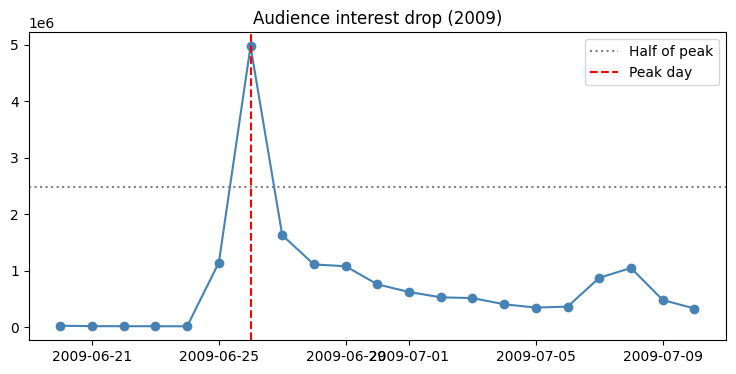

In [10]:
window_plot = pageviews[(pageviews["date"] >= "2009-06-20") & (pageviews["date"] <= "2009-07-15")]

plt.figure(figsize=(9, 4))
plt.plot(window_plot["date"], window_plot["views"], marker="o", color="steelblue")
plt.axhline(peak_value_2009 / 2, color="gray", linestyle=":", label="Half of peak")
plt.axvline(peak_date_2009, color="red", linestyle="--", label="Peak day")
plt.title("Audience interest drop (2009)")
plt.legend()
plt.show()



**Layer 3 Event Comparison: 2009 and 2026**

This step compare the 2009 flashpoint (death) to a second, much smaller
spike in April 2026 (the release of the "Michael" movie), using the same three
signals: peak views, number of edits in the following weeks, and change in
article size.

The Goal is to check whether every attention spike leaves the same kind of trace on
the article, or whether this depends on what caused the spike.

The code must be able to answer to question:      
Did the 2026 spike lead to a comparable increase in edits and
article size, or did it behave differently from the 2009 flashpoint?

The third stage of the pipeline is a side-by-side table and a bar chart comparing both events. Note that the two events differ in kind, not only in year: 2009 was a sudden,
unplanned death, while 2026 was a planned film release, which can also produce
repeated waves of attention (for example around a later streaming release).
This difference should be kept in mind when interpreting the comparison.




In [11]:
def analyze_spike(revisions, pageviews, peak_date, window_before=5, window_after=20):
    peak = pd.Timestamp(peak_date, tz="UTC")
    start, end = peak - pd.Timedelta(days=window_before), peak + pd.Timedelta(days=window_after)

    edits_window = revisions[(revisions["timestamp"] >= start) & (revisions["timestamp"] <= end)]
    size_before = revisions[revisions["timestamp"] <= start]["size_clean"].iloc[-1]
    size_after = revisions[revisions["timestamp"] <= end]["size_clean"].iloc[-1]

    pv_window = pageviews[
        (pageviews["date"] >= pd.Timestamp(peak_date)) &
        (pageviews["date"] <= pd.Timestamp(peak_date) + pd.Timedelta(days=window_after))
    ]
    peak_views = pv_window["views"].max()

    return {
        "peak_date": peak_date,
        "peak_views": int(peak_views),
        "edits_in_window": len(edits_window),
        "size_before": int(size_before),
        "size_after": int(size_after),
        "delta_size_bytes": int(size_after - size_before),
    }


result_2009 = analyze_spike(revisions, pageviews, "2009-06-26")
result_2026 = analyze_spike(revisions, pageviews, "2026-04-26")

comparison = pd.DataFrame([result_2009, result_2026])
comparison


,peak_date,peak_views,edits_in_window,size_before,size_after,delta_size_bytes
0,2009-06-26,4972223,2560,126359,139706,13347
1,2026-04-26,339354,90,358942,358942,0


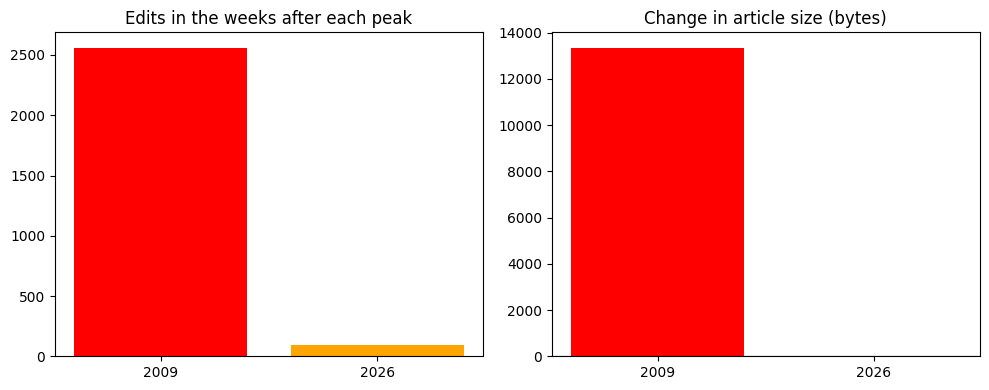

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["2009", "2026"], [result_2009["edits_in_window"], result_2026["edits_in_window"]], color=["red", "orange"])
axes[0].set_title("Edits in the weeks after each peak")

axes[1].bar(["2009", "2026"], [result_2009["delta_size_bytes"], result_2026["delta_size_bytes"]], color=["red", "orange"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Change in article size (bytes)")

plt.tight_layout()
plt.show()


## Summary

